In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

from sklearn.ensemble import RandomForestClassifier
!pip install opacus

from opacus import PrivacyEngine

import matplotlib.pyplot as plt
import hashlib, json

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 9.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Blockchain/creditcard_2023.csv"
df = pd.read_csv(csv_path)
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [ ]:
import pandas as pd

# basic info
print("Shape:", df.shape)

n_samples = df.shape[0]
n_features = df.shape[1] - 1  # Class hariç

fraud_counts = df['Class'].value_counts()

n_fraud = fraud_counts[1]
n_normal = fraud_counts[0]

fraud_rate = (n_fraud / n_samples) * 100

print("Total samples:", n_samples)
print("Number of features:", n_features)
print("Normal transactions:", n_normal)
print("Fraud transactions:", n_fraud)
print("Fraud rate (%):", round(fraud_rate, 4))


Shape: (568630, 31)
Total samples: 568630
Number of features: 30
Normal transactions: 284315
Fraud transactions: 284315
Fraud rate (%): 50.0


In [ ]:
print(df.shape)
print(df.columns)

(568630, 31)
Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [ ]:
df = df.drop("id", axis=1)


X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test  = torch.tensor(y_test.values, dtype=torch.float32)

# MLP MODEL

In [ ]:
class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
def evaluate(y_true, probs):
    pred = (probs > 0.5).astype(int)

    return [
        accuracy_score(y_true, pred),
        precision_score(y_true, pred),
        recall_score(y_true, pred),
        f1_score(y_true, pred),
        roc_auc_score(y_true, probs)
    ]

# Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12)
rf.fit(X_train.numpy(), y_train.numpy())

rf_probs = rf.predict_proba(X_test.numpy())[:,1]

Baseline MLP

In [ ]:
model = MLP(X_train.shape[1])

loader = DataLoader(TensorDataset(X_train,y_train), batch_size=512, shuffle=True)

opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

for epoch in range(10):
    for xb,yb in loader:
        opt.zero_grad()
        loss = loss_fn(model(xb).squeeze(), yb)
        loss.backward()
        opt.step()

baseline_probs = model(X_test).detach().numpy().squeeze()

DP-MLP

In [ ]:
dp_model = MLP(X_train.shape[1])
optimizer = optim.Adam(dp_model.parameters(), lr=0.001)

loader = DataLoader(TensorDataset(X_train,y_train), batch_size=512, shuffle=True)

privacy_engine = PrivacyEngine()

dp_model, optimizer, loader = privacy_engine.make_private_with_epsilon(
    module=dp_model,
    optimizer=optimizer,
    data_loader=loader,
    target_epsilon=3,
    target_delta=1e-5,
    epochs=10,
    max_grad_norm=1.0
)

for epoch in range(10):
    for xb,yb in loader:
        optimizer.zero_grad()
        loss = loss_fn(dp_model(xb).squeeze(), yb)
        loss.backward()
        optimizer.step()

dp_probs = dp_model(X_test).detach().numpy().squeeze()

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/tmp/ipython-input-1840634737.py:22: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


# BLOCKCHAİN LOGGIN

In [ ]:
class Logger:
    def __init__(self):
        self.chain=[]
    def add(self,data):
        prev = self.chain[-1]["hash"] if self.chain else "0"
        entry={"data":data,"prev":prev}
        entry["hash"]=hashlib.sha256(json.dumps(entry).encode()).hexdigest()
        self.chain.append(entry)

logger = Logger()

logger.add({"model":"baseline","auc":roc_auc_score(y_test, baseline_probs)})
logger.add({"model":"dp","auc":roc_auc_score(y_test, dp_probs)})
logger.add({"model":"rf","auc":roc_auc_score(y_test, rf_probs)})

print(logger.chain)

[{'data': {'model': 'baseline', 'auc': np.float64(0.9999624155776898)}, 'prev': '0', 'hash': '332cf91fa6d8dbc6bd9c3673d8f57079c478597dcf14829eef5a202cec110af0'}, {'data': {'model': 'dp', 'auc': np.float64(0.9995665078039696)}, 'prev': '332cf91fa6d8dbc6bd9c3673d8f57079c478597dcf14829eef5a202cec110af0', 'hash': 'a3972b6c502a467d157ba5314a724f8f1158992a884810a55e7fc57d7ac9b66d'}, {'data': {'model': 'rf', 'auc': np.float64(0.9998833918134693)}, 'prev': 'a3972b6c502a467d157ba5314a724f8f1158992a884810a55e7fc57d7ac9b66d', 'hash': '6ad8c7d74abf8a41854f4512209ceec8ccd6022f4a5b5a45a8b4f183f15e7953'}]


Comparasion Table

In [ ]:


results = pd.DataFrame(
    [
        evaluate(y_test, baseline_probs),
        evaluate(y_test, dp_probs),
        evaluate(y_test, rf_probs)
    ],
    columns=["Accuracy","Precision","Recall","F1","AUC"],
    index=["Baseline MLP","DP-MLP","Random Forest"]
)

print(results)

               Accuracy  Precision    Recall        F1       AUC
Baseline MLP   0.999578   0.999192  0.999965  0.999578  0.999962
DP-MLP         0.994970   0.992390  0.997591  0.994984  0.999567
Random Forest  0.994073   0.998899  0.989237  0.994045  0.999883


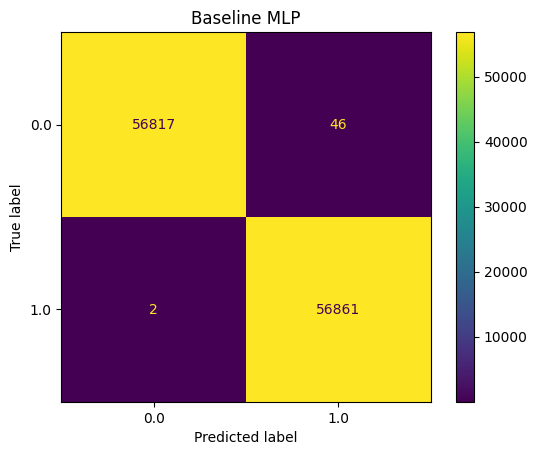

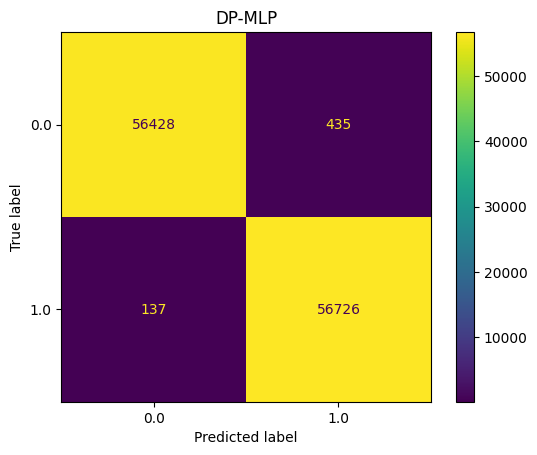

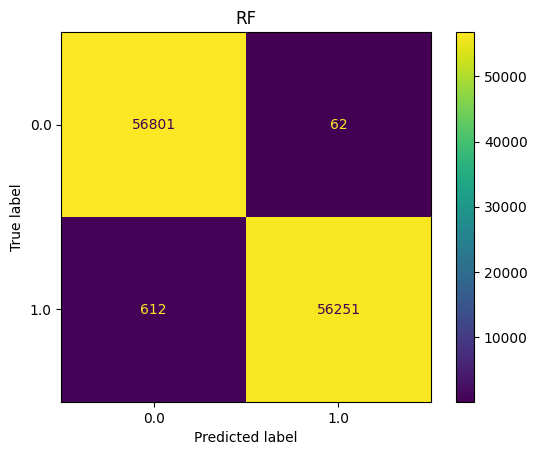

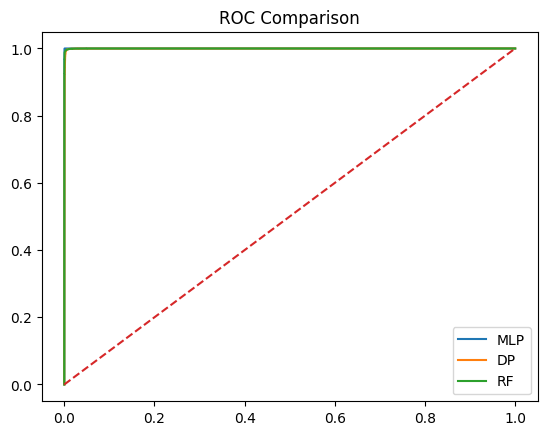

In [ ]:
def plot_cm(y, probs, title):
    pred=(probs>0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(y,pred)
    plt.title(title)
    plt.show()

plot_cm(y_test, baseline_probs, "Baseline MLP")
plot_cm(y_test, dp_probs, "DP-MLP")
plot_cm(y_test, rf_probs, "RF")


for probs,label in [(baseline_probs,"MLP"),(dp_probs,"DP"),(rf_probs,"RF")]:
    fpr,tpr,_=roc_curve(y_test,probs)
    plt.plot(fpr,tpr,label=label)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Comparison")
plt.show()

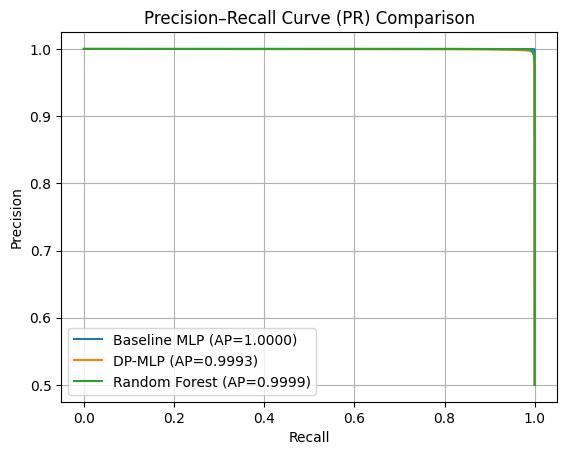

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curves(y_true, probs_dict, title="Precision–Recall Comparison"):
    plt.figure()
    for label, probs in probs_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, probs)
        ap = average_precision_score(y_true, probs)  # Average Precision (AP)
        plt.plot(recall, precision, label=f"{label} (AP={ap:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_pr_curves(
    y_test,
    {
        "Baseline MLP": baseline_probs,
        "DP-MLP": dp_probs,
        "Random Forest": rf_probs
    },
    title="Precision–Recall Curve (PR) Comparison"
)


# Privacy Tradeoff

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/tmp/ipython-input-1548754078.py:62: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for ex

   Accuracy  Precision    Recall        F1       AUC  Target_epsilon  \
0  0.985456   0.988705  0.982132  0.985408  0.998703             0.5   
1  0.988103   0.990042  0.986125  0.988079  0.999056             1.0   
2  0.990046   0.991135  0.988938  0.990035  0.999230             2.0   
3  0.990952   0.991618  0.990275  0.990946  0.999312             3.0   
4  0.992192   0.991950  0.992438  0.992194  0.999415             5.0   
5  0.993775   0.992285  0.995287  0.993784  0.999518            10.0   

   Achieved_epsilon  
0          0.495620  
1          0.998758  
2          1.995702  
3          2.993148  
4          4.996963  
5          9.999836  


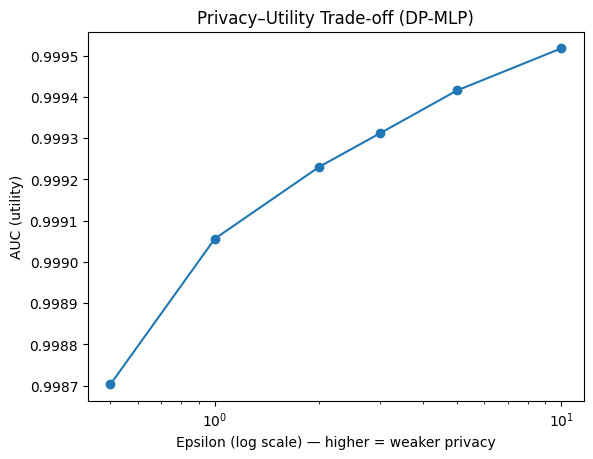

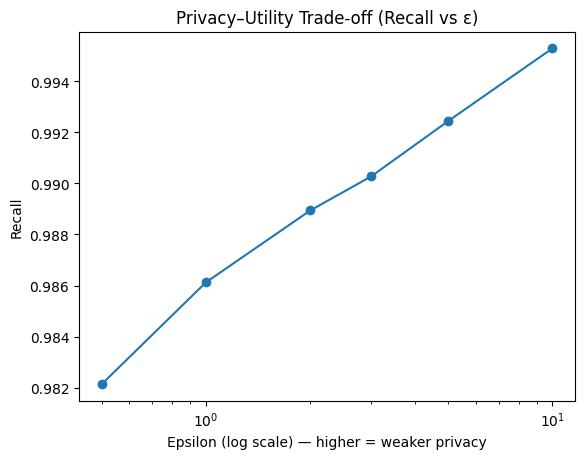

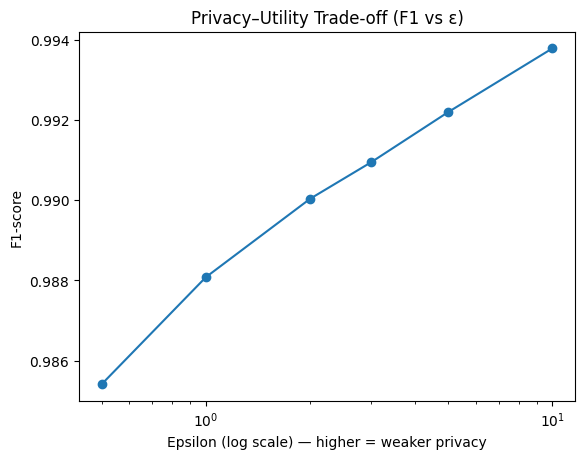

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from opacus import PrivacyEngine


def eval_probs(y_true_tensor, probs_np):
    """y_true_tensor: torch tensor (0/1), probs_np: numpy probs"""
    y_true = y_true_tensor.detach().cpu().numpy().astype(int)
    pred = (probs_np > 0.5).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "AUC": roc_auc_score(y_true, probs_np),
    }


def train_dp_for_epsilon(
    epsilon_target: float,
    epochs: int = 5,
    batch_size: int = 512,
    lr: float = 1e-3,
    max_grad_norm: float = 1.0,
    delta: float = 1e-5,
    seed: int = 42,
):

    torch.manual_seed(seed)
    np.random.seed(seed)

    dp_model = MLP(X_train.shape[1])
    dp_model.train()

    optimizer = optim.Adam(dp_model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    privacy_engine = PrivacyEngine()

    dp_model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=dp_model,
        optimizer=optimizer,
        data_loader=train_loader,
        target_epsilon=epsilon_target,
        target_delta=delta,
        epochs=epochs,
        max_grad_norm=max_grad_norm
    )

    for _ in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = dp_model(xb).squeeze()
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

    dp_model.eval()
    with torch.no_grad():
        probs = dp_model(X_test).squeeze().detach().cpu().numpy()

    achieved_eps = privacy_engine.get_epsilon(delta)
    return probs, float(achieved_eps)




epsilons = [0.5, 1, 2, 3, 5, 10]
epochs = 7

rows = []
for eps in epsilons:
    dp_probs_eps, achieved_eps = train_dp_for_epsilon(eps, epochs=epochs)
    m = eval_probs(y_test, dp_probs_eps)
    m["Target_epsilon"] = eps
    m["Achieved_epsilon"] = achieved_eps
    rows.append(m)

tradeoff_df = pd.DataFrame(rows).sort_values("Target_epsilon")
print(tradeoff_df)


tradeoff_df.to_csv("privacy_utility_tradeoff.csv", index=False)


plt.figure()
plt.plot(tradeoff_df["Target_epsilon"], tradeoff_df["AUC"], marker="o")
plt.xscale("log")
plt.xlabel("Epsilon (log scale) — higher = weaker privacy")
plt.ylabel("AUC (utility)")
plt.title("Privacy–Utility Trade-off (DP-MLP)")
plt.show()

plt.figure()
plt.plot(tradeoff_df["Target_epsilon"], tradeoff_df["Recall"], marker="o")
plt.xscale("log")
plt.xlabel("Epsilon (log scale) — higher = weaker privacy")
plt.ylabel("Recall")
plt.title("Privacy–Utility Trade-off (Recall vs ε)")
plt.show()

plt.figure()
plt.plot(tradeoff_df["Target_epsilon"], tradeoff_df["F1"], marker="o")
plt.xscale("log")
plt.xlabel("Epsilon (log scale) — higher = weaker privacy")
plt.ylabel("F1-score")
plt.title("Privacy–Utility Trade-off (F1 vs ε)")
plt.show()

In [ ]:
tradeoff_df_round = tradeoff_df.round(6)

print("\nTable 4.2 — Privacy–Utility Trade-off")
print(tradeoff_df_round)

tradeoff_df_round.to_csv("table_4_2_privacy_tradeoff.csv", index=False)


Table 4.2 — Privacy–Utility Trade-off
   Accuracy  Precision    Recall        F1       AUC  Target_epsilon  \
0  0.985456   0.988705  0.982132  0.985408  0.998703             0.5   
1  0.988103   0.990042  0.986125  0.988079  0.999056             1.0   
2  0.990046   0.991135  0.988938  0.990035  0.999230             2.0   
3  0.990952   0.991618  0.990275  0.990946  0.999312             3.0   
4  0.992192   0.991950  0.992438  0.992194  0.999415             5.0   
5  0.993775   0.992285  0.995287  0.993784  0.999518            10.0   

   Achieved_epsilon  
0          0.495620  
1          0.998758  
2          1.995702  
3          2.993148  
4          4.996963  
5          9.999836  


Baseline MLP vs DP-MLP vs Random Forest

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)

def to_numpy_1d(x):
    """Accepts torch tensor / numpy array and returns 1D numpy array."""
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    x = np.asarray(x).squeeze()
    return x

def compute_metrics(y_true, prob, threshold=0.5):
    """
    y_true: 0/1 labels
    prob: predicted probabilities for class 1
    """
    y_true = to_numpy_1d(y_true).astype(int)
    prob = to_numpy_1d(prob).astype(float)

    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "AUC": roc_auc_score(y_true, prob),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }



rows = []
rows.append(("Baseline MLP", compute_metrics(y_test, baseline_probs)))
rows.append(("DP-MLP",       compute_metrics(y_test, dp_probs)))
rows.append(("Random Forest",compute_metrics(y_test, rf_probs)))

table_41 = pd.DataFrame(
    [r[1] for r in rows],
    index=[r[0] for r in rows]
)

# Reorder columns nicely for the thesis table
table_41 = table_41[["Accuracy","Precision","Recall","F1","AUC","TP","TN","FP","FN"]]

print("\nTable 4.1 — Model Performance Comparison")
print(table_41.round(6))

table_41.round(6).to_csv("table_4_1_model_comparison.csv")

latex_tbl = table_41[["Accuracy","Precision","Recall","F1","AUC"]].round(6).to_latex()
with open("table_4_1_model_comparison.tex", "w") as f:
    f.write(latex_tbl)

print("\nSaved: table_4_1_model_comparison.csv and table_4_1_model_comparison.tex")


Table 4.1 — Model Performance Comparison
               Accuracy  Precision    Recall        F1       AUC     TP  \
Baseline MLP   0.999578   0.999192  0.999965  0.999578  0.999962  56861   
DP-MLP         0.994970   0.992390  0.997591  0.994984  0.999567  56726   
Random Forest  0.994073   0.998899  0.989237  0.994045  0.999883  56251   

                  TN   FP   FN  
Baseline MLP   56817   46    2  
DP-MLP         56428  435  137  
Random Forest  56801   62  612  

Saved: table_4_1_model_comparison.csv and table_4_1_model_comparison.tex


In [ ]:
print("\nAUC scores:")
print("Baseline:", roc_auc_score(y_test, baseline_probs))
print("DP-MLP:", roc_auc_score(y_test, dp_probs))
print("RF:", roc_auc_score(y_test, rf_probs))


AUC scores:
Baseline: 0.9999624155776898
DP-MLP: 0.9995665078039696
RF: 0.9998833918134693


Blockchain integrity check

In [ ]:
def verify_chain(chain):
    import hashlib, json
    for i in range(1, len(chain)):
        prev_hash = chain[i-1]["hash"]
        entry = {"data": chain[i]["data"], "prev": chain[i]["prev"]}
        recalculated = hashlib.sha256(json.dumps(entry).encode()).hexdigest()
        if chain[i]["prev"] != prev_hash or chain[i]["hash"] != recalculated:
            return False
    return True

print("Chain valid:", verify_chain(logger.chain))

# simulate tampering
logger.chain[1]["data"]["auc"] = 999

print("After tampering:", verify_chain(logger.chain))

Chain valid: True
After tampering: False


In [ ]:
import torch, sklearn, opacus, sys

print(torch.__version__)
print(sklearn.__version__)
print(opacus.__version__)
print(sys.version)


2.9.0+cpu
1.6.1
1.5.4
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:


import re
import time
import math
import json
import inspect
from typing import Any, Dict, List, Tuple

def _safe_str(x: Any, maxlen: int = 200) -> str:
    try:
        s = str(x)
        return s if len(s) <= maxlen else s[:maxlen] + "..."
    except Exception:
        return "<unprintable>"

def _find_in_globals(patterns: List[str], g: Dict[str, Any]) -> List[Tuple[str, Any]]:
    hits = []
    for k, v in g.items():
        if any(re.fullmatch(p, k, flags=re.IGNORECASE) for p in patterns):
            hits.append((k, v))
    return hits

def _find_contains_in_globals(keywords: List[str], g: Dict[str, Any]) -> List[Tuple[str, Any]]:
    hits = []
    for k, v in g.items():
        lk = k.lower()
        if any(kw in lk for kw in keywords):
            hits.append((k, v))
    return hits

def _try_get_keras_fit_epochs(g: Dict[str, Any]) -> Any:
    """
    If user stored history = model.fit(...), then history.params might have epochs.
    """
    for k, v in g.items():
        if k.lower() in ["history", "hist", "train_history"]:
            try:
                params = getattr(v, "params", None)
                if isinstance(params, dict) and "epochs" in params:
                    return params.get("epochs")
            except Exception:
                pass
    return None

def _try_get_keras_optimizer_lr(g: Dict[str, Any]) -> Any:
    """
    Try to locate a Keras optimizer and read its learning rate.
    """
    # common names
    for name in ["optimizer", "opt", "keras_optimizer"]:
        if name in g:
            opt = g[name]
            try:
                lr = getattr(opt, "learning_rate", None)
                if lr is not None:
                    # could be tf.Variable / schedule
                    try:
                        return float(lr.numpy())
                    except Exception:
                        return _safe_str(lr)
            except Exception:
                pass

    # search for any object that looks like a Keras optimizer
    for k, v in g.items():
        try:
            cls = v.__class__.__name__.lower()
            mod = v.__class__.__module__.lower()
            if "keras" in mod and "optim" in mod:
                lr = getattr(v, "learning_rate", None)
                if lr is not None:
                    try:
                        return float(lr.numpy())
                    except Exception:
                        return _safe_str(lr)
        except Exception:
            continue
    return None

def _try_get_torch_optimizer_lr(g: Dict[str, Any]) -> Any:
    """
    Try to locate a torch optimizer and read lr from param_groups.
    """
    for name in ["optimizer", "opt", "torch_optimizer"]:
        if name in g:
            opt = g[name]
            try:
                pg = getattr(opt, "param_groups", None)
                if isinstance(pg, list) and len(pg) > 0 and "lr" in pg[0]:
                    return pg[0]["lr"]
            except Exception:
                pass

    for k, v in g.items():
        try:
            cls = v.__class__.__name__.lower()
            mod = v.__class__.__module__.lower()
            if "torch" in mod and "optim" in mod:
                pg = getattr(v, "param_groups", None)
                if isinstance(pg, list) and len(pg) > 0 and "lr" in pg[0]:
                    return pg[0]["lr"]
        except Exception:
            continue
    return None

def _print_section(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

def _kv_print(k: str, v: Any):
    print(f"- {k}: {_safe_str(v)}")

def dump_experiment_config():
    g = globals()

    _print_section("A) BASIC TRAINING SETTINGS (epochs / batch size / lr)")
    # epochs
    epochs_hits = _find_in_globals(
        patterns=[
            r"epochs", r"epoch", r"num_epochs", r"n_epochs", r"max_epochs",
            r"train_epochs", r"num_epoch"
        ],
        g=g
    )
    if epochs_hits:
        for k, v in epochs_hits:
            _kv_print(k, v)
    else:
        # try from keras history
        ep = _try_get_keras_fit_epochs(g)
        if ep is not None:
            _kv_print("epochs (from Keras History.params)", ep)
        else:
            print("- epochs: <not found by name> (try searching for model.fit(..., epochs=...) or for epoch loops)")

    # batch size
    bs_hits = _find_in_globals(
        patterns=[
            r"batch_size", r"batchsize", r"bs", r"train_batch_size",
            r"loader_batch_size", r"batch"
        ],
        g=g
    )
    if bs_hits:
        for k, v in bs_hits:
            _kv_print(k, v)
    else:
        print("- batch_size: <not found by name>")

    # learning rate
    lr_hits = _find_in_globals(
        patterns=[r"lr", r"learning_rate", r"learn_rate", r"eta"],
        g=g
    )
    if lr_hits:
        for k, v in lr_hits:
            _kv_print(k, v)
    else:
        # try from optimizer objects
        lr = _try_get_keras_optimizer_lr(g)
        if lr is None:
            lr = _try_get_torch_optimizer_lr(g)
        if lr is not None:
            _kv_print("learning_rate (from optimizer)", lr)
        else:
            print("- learning_rate: <not found by name or optimizer>")

    _print_section("B) DIFFERENTIAL PRIVACY SETTINGS (noise / clip / epsilon / delta)")
    # common DP variable names (TensorFlow Privacy / Opacus / custom)
    dp_hits = _find_contains_in_globals(
        keywords=[
            "noise", "sigma", "multiplier", "clip", "clipping", "l2_norm",
            "epsilon", "eps", "delta", "privacy", "dp", "accountant"
        ],
        g=g
    )

    # Filter to likely scalar settings (int/float/str/dict) to avoid dumping huge objects
    shown = 0
    for k, v in sorted(dp_hits, key=lambda x: x[0].lower()):
        if isinstance(v, (int, float, str, bool, dict, list, tuple)) or v is None:
            _kv_print(k, v)
            shown += 1

    if shown == 0:
        print("- DP settings: <not found by variable names>")
        print("  Tip: ensure you store key DP values in variables like noise_multiplier, l2_norm_clip, epsilon, delta")

    _print_section("C) DATASET / SPLIT SUMMARY (if available)")
    # try common names
    ds_hits = _find_contains_in_globals(
        keywords=["x_train", "y_train", "x_test", "y_test", "train_df", "test_df", "label", "target", "y"],
        g=g
    )

    # Print class distribution if we can detect y vectors
    def _class_dist(y):
        try:
            import numpy as np
            y_arr = np.array(y).reshape(-1)
            # if one-hot, reduce
            if y_arr.ndim > 1 and y_arr.shape[-1] > 1:
                y_arr = y_arr.argmax(axis=-1)
            vals, cnts = np.unique(y_arr, return_counts=True)
            return {int(v): int(c) for v, c in zip(vals, cnts)}
        except Exception:
            return None

    printed_any = False
    for k, v in ds_hits:
        if k.lower() in ["y_train", "y_test", "y", "labels", "target", "y_val", "y_valid", "y_validation"]:
            dist = _class_dist(v)
            if dist is not None:
                _kv_print(f"class_distribution({k})", dist)
                printed_any = True

    if not printed_any:
        print("- class distribution: <not found/parsed> (if you have y_train/y_test, ensure they are in variables)")

    _print_section("D) MODEL OBJECTS FOUND (names only)")
    # Just list likely model variables (avoid printing huge reprs)
    model_like = []
    for k, v in g.items():
        lk = k.lower()
        if any(tok in lk for tok in ["model", "mlp", "rf", "randomforest", "classifier", "net"]):
            model_like.append(k)
    if model_like:
        for name in sorted(set(model_like), key=str.lower):
            print(f"- {name}")
    else:
        print("- model variables: <none detected by name>")

    _print_section("E) RUN METADATA")
    _kv_print("timestamp_utc", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()))
    print("\nDone.")

dump_experiment_config()



A) BASIC TRAINING SETTINGS (epochs / batch size / lr)
- epoch: 9
- epochs: 7
- batch_size: <not found by name>
- learning_rate (from optimizer): 0.001

B) DIFFERENTIAL PRIVACY SETTINGS (noise / clip / epsilon / delta)
- achieved_eps: 9.999835665999377
- eps: 10
- epsilons: [0.5, 1, 2, 3, 5, 10]

C) DATASET / SPLIT SUMMARY (if available)
- class_distribution(y): {0: 284315, 1: 284315}
- class_distribution(y_train): {0: 227452, 1: 227452}
- class_distribution(y_test): {0: 56863, 1: 56863}

D) MODEL OBJECTS FOUND (names only)
- dp_model
- MLP
- model
- RandomForestClassifier
- rf
- rf_probs

E) RUN METADATA
- timestamp_utc: 2026-02-13 22:43:01

Done.
